<a href="https://colab.research.google.com/github/jach36/Scallop-Population-CV-Project/blob/main/part1_oceanicAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **-- BEFORE RUNNING --**
### Ensure that the CV-Final-Project and CV-ObjectDetection folders are in your MyDrive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Validate the training data (1:1 match for all images to corresponding annotations)
import os

# Update these paths based on your Drive shortcuts
image_dir = '/content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/images/train'
label_dir = '/content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/labels/train/'

images = {os.path.splitext(f)[0] for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))}
labels = {os.path.splitext(f)[0] for f in os.listdir(label_dir) if f.endswith('.txt')}

missing_labels = images - labels
missing_images = labels - images

print(f"Images without labels: {len(missing_labels)}")
print(f"Labels without images: {len(missing_images)}")

if missing_labels:
    print(f"Example missing labels: {list(missing_labels)[:5]}")

Images without labels: 0
Labels without images: 0


In [ ]:
# Verify annotation formatting (normalized)
import os
import random


label_dir = '/content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/train/labels'
sample_file = random.choice(os.listdir(label_dir))

with open(os.path.join(label_dir, sample_file), 'r') as f:
    lines = f.readlines()
    print(f"Checking file: {sample_file}")
    for line in lines:
        parts = line.split()
        if len(parts) == 5:
            class_id = parts[0]
            # Check if coordinates are normalized (between 0 and 1)
            coords = [float(x) for x in parts[1:]]
            is_normalized = all(0 <= c <= 1 for c in coords)

            print(f"Class: {class_id} | Normalized: {is_normalized} | Values: {coords}")
        else:
            print(f"Malformed line found: {line}")

Checking file: whelk-210_jpg.rf.bf1124ee4238a23c272d129151b96864.txt
Class: 6 | Normalized: True | Values: [0.803125, 0.29609375, 0.0953125, 0.1375]


In [7]:
# install dependencies
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -U ultralytics

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
# Create a local directory
!mkdir -p /content/scallop_data

# Copy everything from shared drive to your local Colab disk (so we have write permissions)
!cp -r -v /content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/* /content/scallop_data/

Streaming output truncated to the last 5000 lines.
'/content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/total/images/Eel-127_jpg.rf.c3508b46764774b5641b87c9be3519e1.jpg' -> '/content/scallop_data/total/images/Eel-127_jpg.rf.c3508b46764774b5641b87c9be3519e1.jpg'
'/content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/total/images/Eel-135_jpg.rf.4d12483825ef381a8d9a7639ccdedf30.jpg' -> '/content/scallop_data/total/images/Eel-135_jpg.rf.4d12483825ef381a8d9a7639ccdedf30.jpg'
'/content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/total/images/Eel-147_jpg.rf.ef896fc87791edd6d927d4e3c04a85a6.jpg' -> '/content/scallop_data/total/images/Eel-147_jpg.rf.ef896fc87791edd6d927d4e3c04a85a6.jpg'
'/content/drive/MyDrive/CV-ObjectDetection/object_detection_dataset/total/images/Eel-13_jpg.rf.b86164975bf6b1b75d8fbe6596f41bbb.jpg' -> '/content/scallop_data/total/images/Eel-13_jpg.rf.b86164975bf6b1b75d8fbe6596f41bbb.jpg'
'/content/drive/MyDrive/CV-ObjectDetection/obje

In [ ]:
import yaml

local_yaml = {
    'path': '/content/scallop_data',
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 7,
    'names': ['crab', 'eel', 'flatfish', 'roundfish', 'scallop', 'skate', 'whelk']
}

with open('/content/local_data.yaml', 'w') as f:
    yaml.dump(local_yaml, f)

In [ ]:

import cv2
import os
from tqdm import tqdm

# Define paths
drive_path = "/content/drive/MyDrive/CV-Final-Project/dataset"
local_cropped = "/content/single_frame_dataset"
years = ["2016", "2018", "2019", "2022", "2024"]

for year in years:
    os.makedirs(f"{local_cropped}/{year}", exist_ok=True)
    in_dir = os.path.join(drive_path, year)
    print(f"Cropping {year}...")

    images = [f for f in os.listdir(in_dir) if f.endswith(('.png', '.jpg'))]
    for name in tqdm(images):
        img = cv2.imread(os.path.join(in_dir, name))
        if img is not None:
            # Crop to the LEFT frame (0 to 1360 pixels) (some images require cropping)
            cv2.imwrite(os.path.join(local_cropped, year, name), img[:, :1360])

Cropping 2016...


100%|██████████| 600/600 [01:59<00:00,  5.02it/s]


Cropping 2018...


100%|██████████| 600/600 [02:27<00:00,  4.07it/s]


Cropping 2019...


100%|██████████| 600/600 [03:09<00:00,  3.17it/s]


Cropping 2022...


100%|██████████| 600/600 [10:52<00:00,  1.09s/it]


Cropping 2024...


100%|██████████| 600/600 [12:40<00:00,  1.27s/it]


In [ ]:
from ultralytics import YOLO

# Load the pretrained model
model = YOLO('/content/yolov8s.pt')

# Start training using the YAML inside the scallop_data folder
results = model.train(
    data='/content/scallop_data/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='scallop_detection'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/scallop_data/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

KeyboardInterrupt: 

In [ ]:
# Create a folder in your drive for your models
!mkdir -p /content/drive/MyDrive/models/

# Copy over the weights (may need to change paths depending on MyDrive format)
!cp /content/runs/detect/scallop_detection/part1_detection/weights/best.pt /content/drive/MyDrive/models/scallop_weights.pt
print("Model saved to drive.")

cp: cannot stat '/content/runs/detect/scallop_detection/part1_detection/weights/best.pt': No such file or directory
Model saved to drive.


In [ ]:
import os
import pandas as pd
from ultralytics import YOLO

# replace with path of model
model_path = '/content/runs/detect/scallop_detection/part1_detection/weights/best.pt'
if not os.path.exists(model_path):
    print("Warning: Local path lost. Loading from Google Drive instead...")
    model_path = '/content/drive/MyDrive/models/scallop_v3.pt'

model = YOLO(model_path)

drive_path = "/content/drive/MyDrive/CV-Final-Project/dataset"
years = ["2016", "2018", "2019", "2022", "2024"]

results_list = []

for year in years:
    folder_path = os.path.join(drive_path, year)
    if not os.path.exists(folder_path):
        print(f"Skipping {year}, folder not found.")
        continue

    print(f"Analyzing {year}...")

    # Use stream=True to prevent RAM crashes (deletes from RAM after detection)
    results_generator = model.predict(
        source=folder_path,
        save=True,
        save_txt=True,
        conf=0.3,
        project="Population_Analysis",
        name=year,
        stream=True
    )

    total_found = 0
    img_count = 0

    # Iterate through the generator one by one
    for r in results_generator:
        total_found += len(r.boxes)
        img_count += 1

    results_list.append({
        "Year": year,
        "Total Images": img_count,
        "Total Scallops": total_found,
        "Scallops Per Image": round(total_found / img_count, 2) if img_count > 0 else 0
    })

summary_df = pd.DataFrame(results_list)
print("\n--- Scallop Population Summary Table ---")
print(summary_df)
summary_df.to_csv("scallop_population_results.csv", index=False)

Analyzing 2016...

image 1/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160529.193016740.51961.png: 512x640 1 scallop, 419.8ms
image 2/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160529.193033463.52061.png: 512x640 1 scallop, 439.4ms
image 3/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160529.193041838.52111.png: 512x640 1 scallop, 427.6ms
image 4/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160529.193050202.52161.png: 512x640 1 scallop, 680.2ms
image 5/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160529.193058578.52211.png: 512x640 1 scallop, 624.3ms
image 6/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160529.193123690.52361.png: 512x640 2 scallops, 440.7ms
image 7/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160529.193256068.52911.png: 512x640 1 scallop, 428.6ms
image 8/600 /content/drive/MyDrive/CV-Final-Project/dataset/2016/201503.20160

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import

df = pd.read_csv("scallop_population_results.csv")

plt.figure(figsize=(10, 6))
sns.lineplot(x=df["Year"], y=df["Scallops Per Image"], marker='o', linewidth=2.5, color='#2c7bb6')
plt.fill_between(df["Year"], df["Scallops Per Image"], alpha=0.2, color='#2c7bb6')

plt.title('Scallop Population Trend (2015 - 2024)', fontsize=16)
plt.xlabel('Survey Year', fontsize=12)
plt.ylabel('Average Scallops per Image', fontsize=12)
plt.xticks(df["Year"])
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, df["Scallops Per Image"].max() + 0.5)

plt.savefig('population_trend.png', dpi=300)
plt.show()

In [41]:
import os
import pandas as pd
import cv2
import numpy as np
from ultralytics import YOLO, SAM
from tqdm import tqdm

# --- 1. SETTINGS & PATHS ---
# Toggle this to run all images (takes very long)
RUN_FULL_DATASET = False
# Change to desired number of images per year
num_imgs = 3

drive_path = '/content/drive/MyDrive/CV-Final-Project/dataset'
csv_path = '/content/drive/MyDrive/CV-Final-Project/index.csv'
yolo_model = YOLO('/content/drive/MyDrive/models/best.pt')
sam_model = SAM('mobile_sam.pt')

df_metadata = pd.read_csv(csv_path)
df_metadata['folder'] = df_metadata['folder'].astype(str)

if RUN_FULL_DATASET:
    df_to_process = df_metadata
    output_filename = 'scallop_measurements.csv'
    print("--- Starting Full Analysis ---")
else:
    df_to_process = df_metadata.groupby('folder').head(num_imgs)
    output_filename = f'scallop_measurements.csv'
    print(f"--- Starting BALANCED Sample Analysis ( {num_imgs} per year) ---")

print(f"Total images to process: {len(df_to_process)}")

results_list = []

def process_images(metadata_df, base_path):
    for index, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Analyzing"):
        subfolders = ['', 'train', 'test', 'val']
        image_path = None

        for sub in subfolders:
            test_path = os.path.join(base_path, str(row['folder']), sub, row['Imagename'])
            if os.path.exists(test_path):
                image_path = test_path
                break

        if image_path is None or pd.isna(row['fov']):
            continue

        yolo_results = yolo_model(image_path, conf=0.25, verbose=False)

        for result in yolo_results:
            boxes = result.boxes.xyxy
            if len(boxes) == 0: continue

            sam_results = sam_model.predict(image_path, bboxes=boxes, verbose=False)
            masks = sam_results[0].masks.data
            mm_per_pixel = (float(row['fov']) * 1000) / 1280

            for i, mask in enumerate(masks):
                mask_np = mask.cpu().numpy().astype(np.uint8)
                contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                if contours:
                    (x, y), radius = cv2.minEnclosingCircle(contours[0])
                    real_size_mm = (radius * 2) * mm_per_pixel
                    results_list.append({
                        'Year': row['folder'],
                        'Image': row['Imagename'],
                        'Size_mm': real_size_mm,
                        'Lat': row['lat'],
                        'Lon': row['lon']
                    })

process_images(df_to_process, drive_path)

if results_list:
    final_df = pd.DataFrame(results_list)
    final_df.to_csv(output_filename, index=False)
    print(f"\nDONE: Data saved to {output_filename}")
else:
    print("\nWARNING: No scallops found. Check paths or model confidence.")

--- Starting BALANCED Sample Analysis ( 3 per year) ---
Total images to process: 18


Analyzing: 100%|██████████| 18/18 [01:05<00:00,  3.62s/it]


DONE: Data saved to scallop_measurements.csv


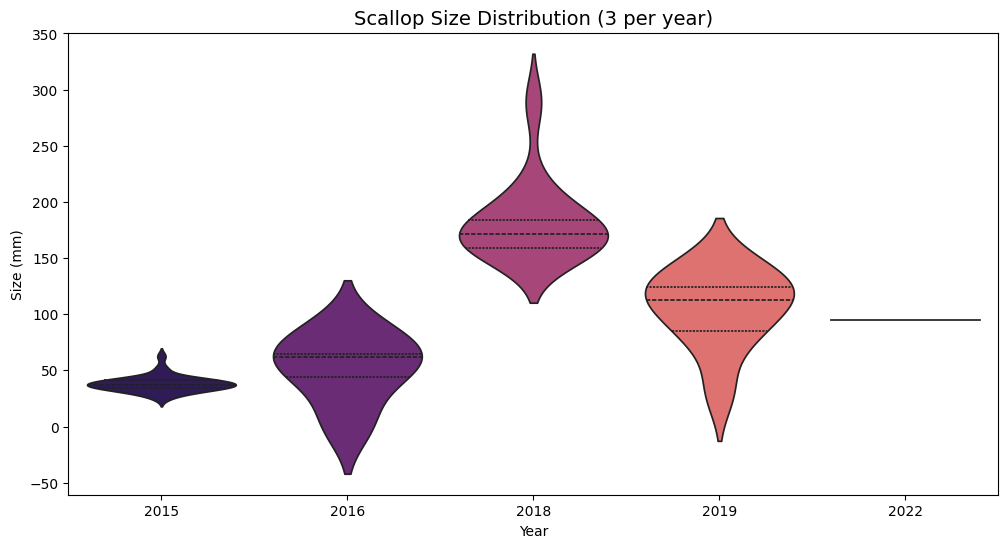

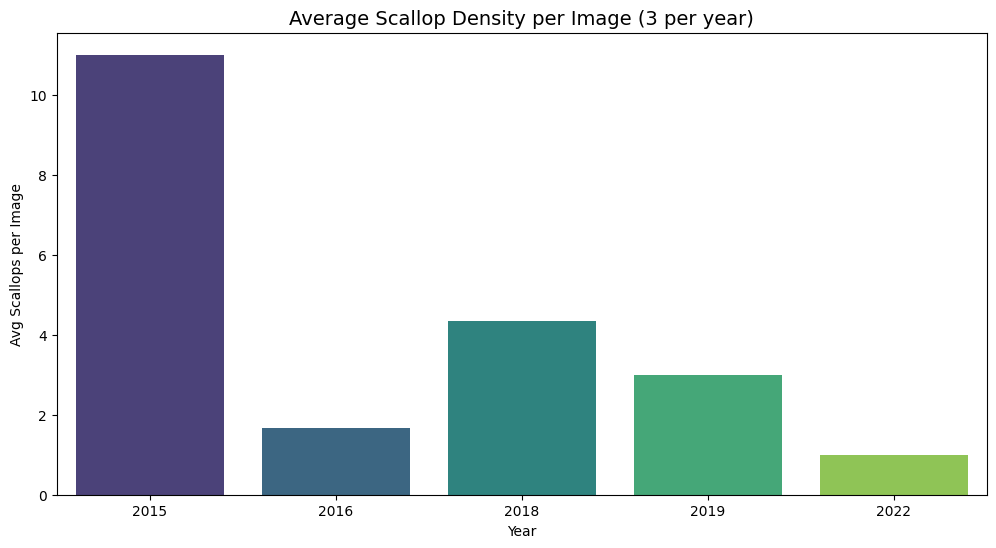

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
csv_file = 'scallop_measurements.csv'
df = pd.read_csv(csv_file)

images_per_year = df.groupby('Year')['Image'].nunique().max()

if images_per_year <= 50:
    sample_desc = f" ({images_per_year} per year)"
else:
    sample_desc = ""

df['Year'] = df['Year'].astype(str)
year_order = sorted(df['Year'].unique())

# Size evolution graph
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Year', y='Size_mm', order=year_order,
               inner="quart", palette="magma",
               hue='Year', legend=False)
plt.title(f'Scallop Size Distribution{sample_desc}', fontsize=14)
plt.ylabel('Size (mm)')
plt.savefig('scallop_morphology_violin.png', dpi=300)
plt.show()


density = df.groupby(['Year', 'Image']).size().reset_index(name='count')
avg_density = density.groupby('Year')['count'].mean().reindex(year_order).reset_index()

# Scallop density graph
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_density, x='Year', y='count', palette='viridis',
            order=year_order,
            hue='Year', legend=False)
plt.title(f'Average Scallop Density per Image{sample_desc}', fontsize=14)
plt.ylabel('Avg Scallops per Image')
plt.savefig('scallop_density_bar.png', dpi=300)
plt.show()